In [ ]:
import zipfile
import os

In [ ]:
import zipfile
import os

zip_path = f"/content/balanced_labeled_photos.zip"
extract_path = "/content/balanced_labeled_photos"

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction successful.")
except zipfile.BadZipFile:
    print("The uploaded file is not a valid ZIP file.")

Extraction successful.


In [ ]:
import os
import glob

# Correct path to the class folders
base_dir = "/content/balanced_labeled_photos/balanced_labeled_photos"

# Verify the classes
class_names = os.listdir(base_dir)
print("Classes found:", class_names)

# Count number of images in each class
print("\n Image count per class:")
for class_name in class_names:
    class_path = os.path.join(base_dir, class_name)
    num_images = len(glob.glob(os.path.join(class_path, '*')))
    print(f"{class_name}: {num_images} images")

Classes found: ['menu', 'food', 'inside', 'drink', 'outside']

 Image count per class:
menu: 20000 images
food: 20000 images
inside: 20000 images
drink: 15670 images
outside: 18569 images


## Downsampling the images to 1000

In [ ]:
import os
import shutil
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

# Paths
original_dir = "/content/balanced_labeled_photos/balanced_labeled_photos"
balanced_dir = "/content/svm_ready_data"
train_dir = os.path.join(balanced_dir, 'train')
test_dir = os.path.join(balanced_dir, 'test')

# Parameters
min_images = 1000
split_ratio = 0.8

# Clean old output dirs
shutil.rmtree(balanced_dir, ignore_errors=True)

# Process each class
for cls in os.listdir(original_dir):
    cls_path = os.path.join(original_dir, cls)
    images = os.listdir(cls_path)
    random.shuffle(images)

    selected_images = images[:min_images]

    # Split
    split_index = int(split_ratio * min_images)
    train_imgs = selected_images[:split_index]
    test_imgs = selected_images[split_index:]

    # Create output folders
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    # Copy train images
    for img in tqdm(train_imgs, desc=f"Copying {cls} train"):
        shutil.copy(os.path.join(cls_path, img), os.path.join(train_dir, cls, img))

    # Copy test images
    for img in tqdm(test_imgs, desc=f"Copying {cls} test"):
        shutil.copy(os.path.join(cls_path, img), os.path.join(test_dir, cls, img))

print("Downsampled and split to 1000 per class successfully.")

Copying outside test: 100%|██████████| 200/200 [00:00<00:00, 5081.76it/s]

Downsampled and split to 1000 per class successfully.


## Visualizing to Verify the Downsample

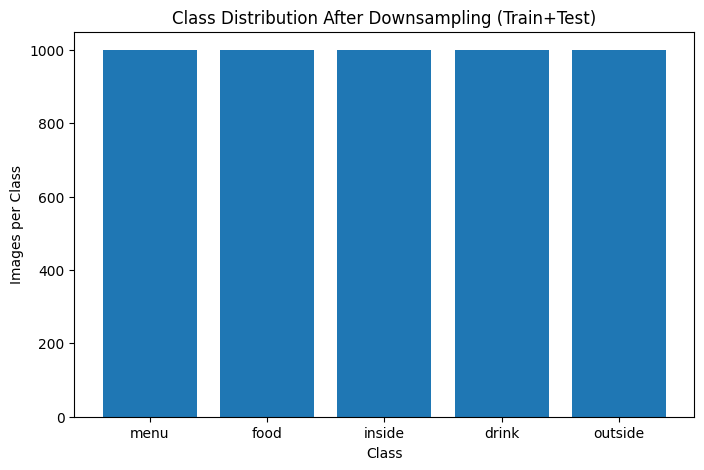

In [ ]:
# Visualize new class distribution
plt.figure(figsize=(8,5))
plt.bar(os.listdir(original_dir), [min_images]*5)
plt.title("Class Distribution After Downsampling (Train+Test)")
plt.ylabel("Images per Class")
plt.xlabel("Class")
plt.show()

In [ ]:
## Importing necessary libraries
import os
import numpy as np
from sklearn import svm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## Load Images
def load_dataset(base_path, img_size=(32, 32)):
    X, y = [], []
    class_names = sorted(os.listdir(base_path))

    for label in class_names:
        class_folder = os.path.join(base_path, label)
        for img_file in tqdm(os.listdir(class_folder), desc=f"Loading {label}"):
            try:
                img_path = os.path.join(class_folder, img_file)
                img = load_img(img_path, target_size=img_size)
                img_array = img_to_array(img) / 255.0
                X.append(img_array.flatten())
                y.append(label)
            except Exception as e:
                continue
    return np.array(X), np.array(y)

X_train, y_train = load_dataset("/content/svm_ready_data/train")
X_test, y_test = load_dataset("/content/svm_ready_data/test")

print(f" Loaded {len(X_train)} training and {len(X_test)} testing samples.")

Loading outside: 100%|██████████| 200/200 [00:00<00:00, 1543.36it/s]

 Loaded 4000 training and 1000 testing samples.


In [ ]:
## Encode and Scale
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## PCA
### Reducing the features


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=300, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

## Train the SVM Model

In [ ]:
clf = svm.SVC(kernel='rbf', probability=True)
clf.fit(X_train_scaled, y_train_enc)
print("SVM model trained.")

SVM model trained.


In [ ]:
# Predict
y_pred = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Accuracy
accuracy = accuracy_score(y_test_enc, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Full classification report
print("Classification Report:")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Accuracy: 0.6890
Classification Report:
              precision    recall  f1-score   support

       drink       0.58      0.58      0.58       200
        food       0.78      0.75      0.77       200
      inside       0.65      0.80      0.72       200
        menu       0.72      0.67      0.69       200
     outside       0.73      0.65      0.69       200

    accuracy                           0.69      1000
   macro avg       0.69      0.69      0.69      1000
weighted avg       0.69      0.69      0.69      1000



## Confusion Matrix

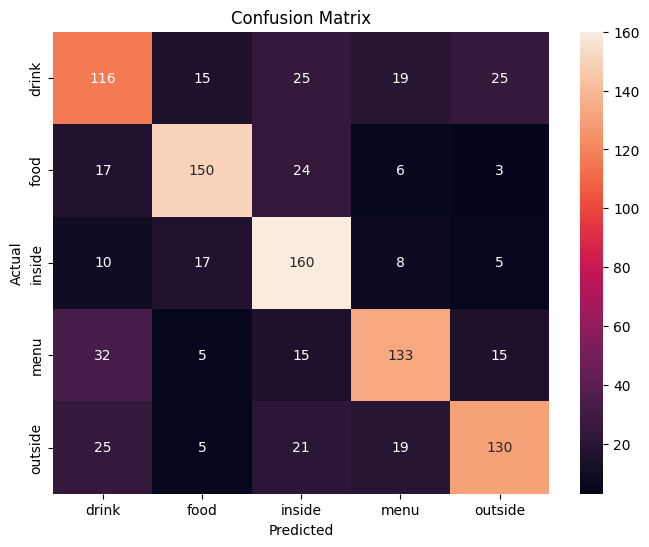

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## ROC Curve + AUC Score

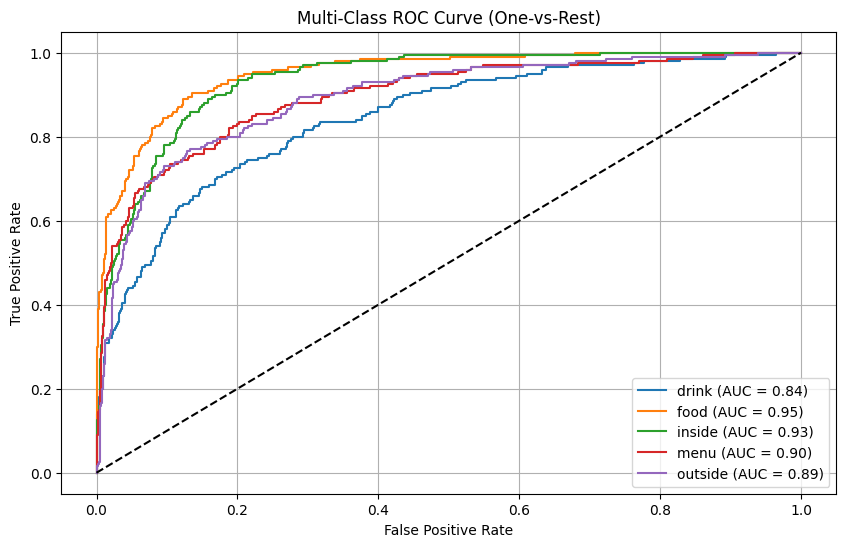

Macro AUC Score: 0.9029


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize test labels for one-vs-rest ROC
y_test_bin = label_binarize(y_test_enc, classes=range(len(le.classes_)))

# ROC Curve per class
plt.figure(figsize=(10, 6))
for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Multi-Class ROC Curve (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Macro AUC Score
auc_macro = roc_auc_score(y_test_enc, y_proba, multi_class='ovr')
print(f"Macro AUC Score: {auc_macro:.4f}")